In [ ]:
# | include: false
using Plots
using LaTeXStrings
using Statistics
using LinearAlgebra
using Roots
using Printf

In [ ]:
# | include: false

function relaxation( f, λ, x1; N=100, tol=1e-12)
    x = [x1]
    r = 0.;
    for n in 2:N
        push!( x, x[n-1] - λ*f(x[n-1]) )
        r = abs(f(x[end]));
        if (r < tol)
            return x
        end
    end
    @warn "max interations |f| = $r";
    return x
end

function Newton( f, f_prime, x1; N=100, tol=1e-12)
    x = [x1]
    r = 0;
    for n in 2:N
        push!( x, x[n-1] - f(x[n-1])/f_prime(x[n-1]) )
        r = abs(f(x[end]));
        if (r < tol)
            return x
        end
    end
    @warn "max interations |f| = $r";
    return x
end

# asymptotic rate of convergence
function μ( x, ξ; α=1 )
    return @. abs( x[2:end] - ξ ) / ( abs(x[1:end-1] - ξ )^α );
end 

ϵ = 1.;
f = ψ -> ψ - ϵ * sin(ψ) - 2π; # has a zero at 2π
ξ = 2π

6.283185307179586

---
format:
  html:
    title: "Ostrowsky's Method"
    author: "Khoi Duong"
---


# Ostrowsky's Method

Ostrowski's method for root-finding is a method that is in some ways faster than the classical Newton's method. It consists of a Newton step plus a correction step: 
$$
\begin{aligned}
y_n &= x_n - \frac{f(x_n)}{f'(x_n)},\\[6pt]
x_{n+1} &= y_n - \frac{f(y_n)}{f'(x_n)}\cdot\frac{f(x_n)}{\,f(x_n)-2f(y_n)\,}.
\end{aligned}
$$

## Order of convergence
Let $\alpha$ be the root we are finding, $x_n$ be the value at step $n$, and $e_n = x_n-\alpha$ be the error at step $n$. Expand $f$ about $\alpha$:
$$
f(\alpha+e)=c_1 e + \tfrac{c_2}{2}e^2 + \tfrac{c_3}{6}e^3 + \tfrac{c_4}{24}e^4 + \cdots,
$$
where $c_k=f^{(k)}(\alpha)$.

Applying to the Newton step:
$$
y_n-\alpha = e_n^2\frac{c_2}{2c_1} + e_n^3\!\left(\frac{c_3}{3c_1}-\frac{c_2^2}{2c_1^2}\right) + O(e_n^4).
$$

Expand $f(y_n)$ using the obtained value of $y_n$: 
$$
f(y_n) = \frac{c_2}{2}e_n^2 + \left(\frac{c_3}{3}-\frac{c_2^2}{2c_1}\right)e_n^3 + O(e_n^4).
$$

Substitute into the Ostrowski correction
$$
x_{n+1}-\alpha = (y_n-\alpha)-\frac{f(y_n)}{f'(x_n)}\frac{f(x_n)}{f(x_n)-2f(y_n)}.
$$

A Taylor expansion (collecting lowest nonzero power) shows that the $e_n^2$ and $e_n^3$ terms cancel and the leading term is $\propto e_n^4$. Concretely,
$$
e_{n+1} := x_{n+1}-\alpha = -\,\frac{c_2 c_3}{12 c_1^2}\; e_n^{4} + O(e_n^5).
$$

Replacing $c_k$ by derivatives at $\alpha$ gives the asymptotic error constant:
$$
e_{n+1} = -\,\frac{f''(\alpha)\,f^{(3)}(\alpha)}{12\,(f'(\alpha))^2}\; e_n^4 + O(e_n^5).
$$

## Efficiency
To evaluate how fast this is, we use the concept of _efficiency_. The _efficiency index_ is defined as $p^\frac1d$, where $p$ is the order of convergence, and $d$ is the number of function invocations per step. This describes how much precision you gain _per function invocation_, which is often the bottleneck in evaluation.  

Note that Newton's method has efficiency $I = 2^\frac12 \approx 1.4142$. Ostrowski's method is order $4$, giving efficiency $I = 4^\frac13 \approx 1.5874$. This is higher than Newton's method (but still lower than, say, the secant method, with efficiency $\frac{1+\sqrt{5}}{2} \approx 1.6180$).

It is, however, optimal in the sense of the Kung-Traub conjecture: for multipoint methods without memory that use $d$ function evaluations per iteration, the maximal attainable order is
$$
p_{\max}=2^{\,d-1}.
$$

Methods achieving this are called _optimal_ (in the Kung–Traub sense). That gives an upper bound on the best possible efficiency index for fixed $d$:
$$
I_{\max}= (2^{\,d-1})^{1/d} = 2^{(d-1)/d}.
$$

## Pathological case: Derivative goes to infinity 
This usually happens when a function has a cusp/vertical tangent at the root: locally,
$$
f(\alpha+e)\sim C\,e^{p},\qquad 0<p<1,
$$
so $f'(\alpha+e)\sim C p\,e^{\,p-1}$ blows up as $e\to0$. 

Below is a asymptotic analysis of the behavior of Newton's method and Ostrowski's method in this case.

1. Newton's method  
    For $f(\alpha+e)=C e^{p}$ with $0<p<1$ and $e$ small,
    $$
    f'(\alpha+e)\approx C p\,e^{p-1},
    $$
    so the Newton step yields
    $$
    y = x - \frac{f(x)}{f'(x)} \quad\Longrightarrow\quad
    y-\alpha = e - \frac{Ce^{p}}{C p e^{p-1}} = e\left(1-\frac{1}{p}\right)=:\lambda e.
    $$

    Thus Newton gives the linear map $e\mapsto \lambda e$ with
    $$
    \lambda = 1-\frac{1}{p}.
    $$

    Convergence requires $|\lambda|<1$, i.e.
    $$
    \left|1-\frac{1}{p}\right|<1 \quad\Longleftrightarrow\quad p>\tfrac12.
    $$

    So Newton converges linearly only when $p>1/2$; for $p\le 1/2$ it fails. Example: $p=1/3$ (the cube-root), Newton has factor $1-3=-2$ and indeed diverges.

2. Ostrowski’s method  

    Use the usual two-stage Ostrowski step
    $$
    y=x-\frac{f(x)}{f'(x)},\qquad
    x_{\text{new}}=y-\frac{f(y)}{f'(x)}\cdot\frac{f(x)}{\,f(x)-2f(y)\,}.
    $$

    With the same local model $f(\alpha+e)=C e^{p}$ one computes (drop higher-order terms)
    $$
    y-\alpha=\lambda e,\qquad
    f(y)=C(\lambda e)^{p}=C\lambda^{p} e^{p},\qquad
    f'(x)\approx Cp\,e^{p-1}.
    $$

    Substituting into the correction term gives (leading order)
    $$
    e_{\,\text{new}}=e_{n+1}=e\!\left(\lambda - \frac{\lambda^{p}}{p\big(1-2\lambda^{p}\big)}\right)+o(e).
    $$

    So Ostrowski is also asymptotically linear in this singular-derivative case. Define the linear factor
    $$
    R(p)\;=\;\lambda - \frac{\lambda^{p}}{p(1-2\lambda^{p})},\qquad
    \lambda=1-\frac{1}{p}.
    $$

    Convergence of Ostrowski requires $|R(p)|<1$. Solving that numerically one finds a critical exponent
    $$
    p_{\rm crit}\approx 0.32053\ldots
    $$

    So:
    - If $p>p_{\rm crit}\ (\approx0.32053)$ then Ostrowski converges linearly (with factor $R(p)$).
    - If $p\le p_{\rm crit}$ Ostrowski fails (the linear factor has magnitude $\ge1$ and iteration does not contract).

Ostrowski's method is more robust than Newton's, but it still failes for small enough exponents. Of course, in these cases, we should probably use something like bisection instead.

## Derivative-free variants
We can use the Steffensen approximation
$$
f'(x) \approx \frac{f(x + f(x)) - f(x)}{f(x)},
$$
however, this is only order $3$. 

We can use another approximation
$$
f'(x) \approx \frac{f(x + f(x)^2)-f(x)}{f(x)^2},
$$
which preserves the order and the number of function invocations. 

## Citation  

@ChristianBeleaPostigo2023: Postigo, N. C. B. (2023). Ostrowski’s method for solving nonlinear equations and systems. _Journal of Mechanics Engineering and Automation, 13_(1). https://doi.org/10.17265/2159-5275/2023.01.001

In [9]:
# Ostrowski's method
function ostrowski(f, f′, x0; N=100, tol=1e-12)
    xs = [x0]
    for k in 1:N
        x = xs[end]
        fx = f(x)
        f′x = f′(x)
        y = x - fx / f′x
        fy = f(y)
        xnext = y - (fy / f′x) * (fx / (fx - 2fy))
        push!(xs, xnext)
        if abs(f(xnext)) < tol
            return xs
        end
    end
    return xs
end

# Derivative-free Ostrowski
function ostrowski_df(f, x0; N=100, tol=1e-12)
    xs = [x0]
    for k in 1:N
        x = xs[end]
        fx = f(x)
        f′_approx = (f(x + fx^2) - fx) / (fx^2)
        y = x - fx / f′_approx
        fy = f(y)
        xnext = y - (fy / f′_approx) * (fx / (fx - 2fy))
        push!(xs, xnext)
        if abs(f(xnext)) < tol
            return xs
        end
    end
    return xs
end

# Bisection method
function bisection(f, a, b; N=100, tol=1e-12)
    fa, fb = f(a), f(b)
    if fa * fb > 0
        error("Bisection: f(a) and f(b) must have opposite signs")
    end
    xs = [(a+b)/2]
    for k in 1:N
        c = (a+b)/2
        fc = f(c)
        push!(xs, c)
        if abs(fc) < tol || (b-a)/2 < tol
            return xs
        end
        if fa * fc < 0
            b, fb = c, fc
        else
            a, fa = c, fc
        end
    end
    return xs
end

bisection (generic function with 1 method)

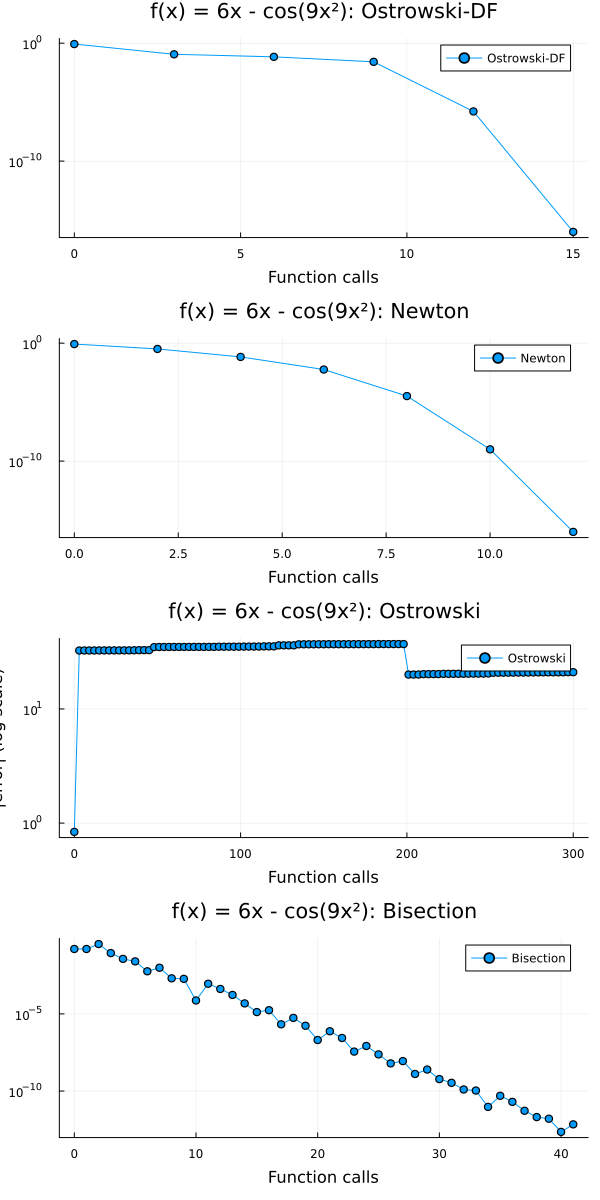

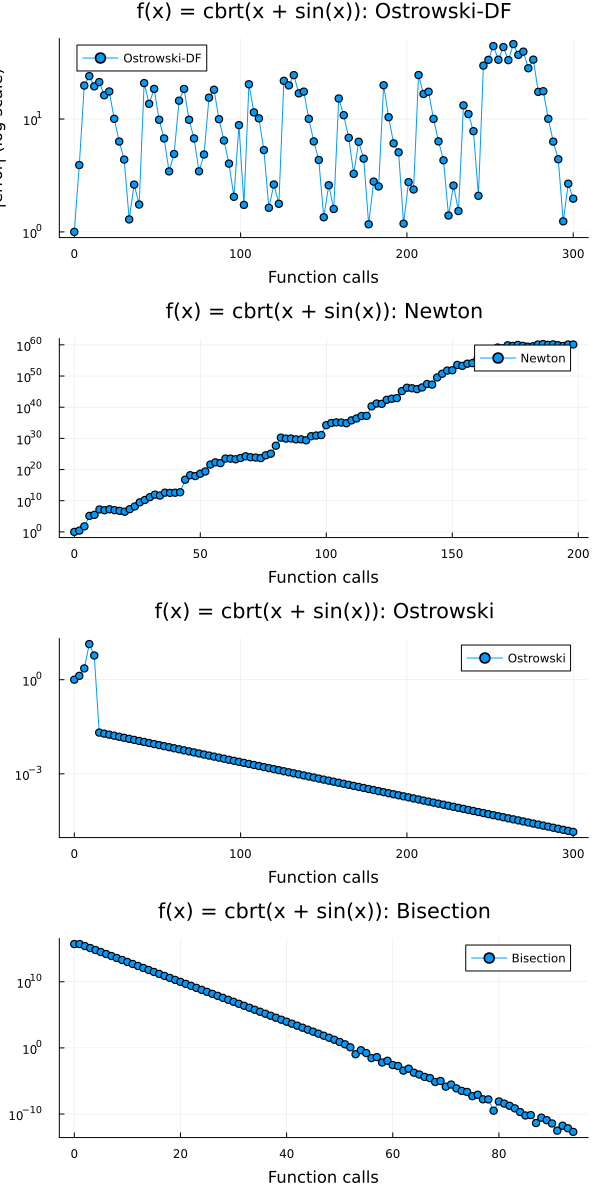

┌ Warning: max interations |f| = 1.0942440181415374e20
└ @ Main c:\Users\minhk\Documents\Assignments\MATH 5485\HW4\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:25


In [10]:
let 
    f1(x) = 6x - cos(9x^2)
    f1′(x) = 6 + 18x * sin(9x^2)

    f2(x) = cbrt(x + sin(x))
    f2′(x) = (1 + cos(x)) / (3 * cbrt((x + sin(x))^2))

    root1 = find_zero(f1, 1)
    root2 = find_zero(f2, 1)

    function run_methods(f, f′, x0, a, b, root; name="")
        results = Dict()

        xs = Newton(f, f′, x0)
        results["Newton"] = abs.(xs .- root)

        xs = ostrowski(f, f′, x0)
        results["Ostrowski"] = abs.(xs .- root)

        xs = ostrowski_df(f, x0)
        results["Ostrowski-DF"] = abs.(xs .- root)

        xs = bisection(f, a, b)
        results["Bisection"] = abs.(xs .- root)

        return results
    end

    results1 = run_methods(f1, f1′, 1.0, -1.0, 1.0, root1; name="f1")
    results2 = run_methods(f2, f2′, 1.0, -1e16, 1.0, root2; name="f2")

    function plot_separate(results, title_str)
        plt = plot(layout=(length(results),1), size=(600, 1200),
                xlabel="Function calls", ylabel="|error| (log scale)")

        i = 1
        for (method, errs) in results
            errs = collect(errs)
            eps_plot = 1e-16  # just above machine epsilon
            errs_safe = max.(errs, eps_plot)
            n = length(errs)
            calls = if method == "Newton"
                2 .* (0:n-1)
            elseif method == "Ostrowski" || method == "Ostrowski-DF"
                3 .* (0:n-1)
            elseif method == "Bisection"
                1 .* (0:n-1)
            else
                0:n-1
            end

            plot!(plt[i], calls, errs_safe,
                yscale=:log10,
                marker=:circle, label=method,
                title="$title_str: $method")
            i += 1
        end
        return plt
    end

    # Example usage:
    p1 = plot_separate(results1, "f(x) = 6x - cos(9x²)")
    p2 = plot_separate(results2, "f(x) = cbrt(x + sin(x))")

    display(p1)
    display(p2)
end
